## Simple LangGraph LLM Reporter (No Web Search)

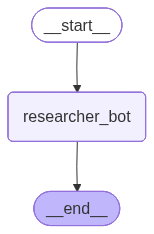

**Report: Latest Trends in Agentic AI for 2026**

**Introduction**

Agentic AI, also known as intelligent agents or autonomous systems, has been a rapidly evolving field in recent years. As we approach 2026, it's essential to identify the latest trends and advancements in agentic AI that will shape its future applications and impact on society. This report provides an overview of the current state of agentic AI research and development, highlighting key trends, challenges, and opportunities.

**Main Section**

1. **Increased Focus on Explainability and Transparency**: With growing concerns about accountability and trustworthiness in AI systems, researchers are placing greater emphasis on developing methods to explain and interpret agentic AI decision-making processes.
2. **Advancements in Multi-Agent Systems (MAS)**: MAS is becoming increasingly important as it enables complex interactions between multiple intelligent agents, leading to improved coordination, cooperation, and conflict 

In [ ]:
#A simple langgraph which just use the llm model to answer my query(NO WEB SEARCH)

from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from utils import draw_graph

#Foundation model
llm_model = ChatOllama(model="llama3.1:latest")
generate_prompt = SystemMessage(
    """You are a reseracher who create a report based on user query.
    This report should have an Introduction section, Main section and conclusion at least.""")

class State(TypedDict):
    messages: Annotated[list, add_messages]

def research_bot(state:State):
    messages = [generate_prompt, *state["messages"]]
    answer = llm_model.invoke(messages)
    return {"messages": [answer]}

#Now build the graph
builder = StateGraph(State)
builder.add_node("researcher_bot", research_bot)
builder.add_edge(START, 'researcher_bot')
builder.add_edge("researcher_bot", END)
graph = builder.compile()

#Draw the graph
draw_graph(graph)

#Final test
query = {"messages": [HumanMessage("What are the latest trends in agentic AI for 2026?")]}
for part in graph.stream(query, stream_mode="messages", version="v2"):
    if part["type"] == "messages":
        message_chunk, metadata = part["data"]
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)


## Adding Web Search Tools to the LangGraph Agent

**DuckDuckGoSearchRun**  
Description (paraphrased):  
A web search tool that queries DuckDuckGo and returns recent, relevant search results (snippets, titles, links) for a given query string.

Use when you need general web search or fresh news, not just encyclopedic facts.

**WikipediaQueryRun**  
Description (from its docstring, lightly paraphrased):  
A wrapper around Wikipedia, useful for answering general questions about people, places, companies, facts, historical events, and other subjects. The input should be a search query.

Use when you want encyclopedia‑style background on a named topic.

**TavilySearchResults**  
Description (from its docs, paraphrased):  
A tool that queries the Tavily Search API and returns a structured JSON response with URLs, content, optional summarized answer, raw content, images, and metadata for a given query.

Use when you want web search with structured, aggregated results (and you have TAVILY_API_KEY

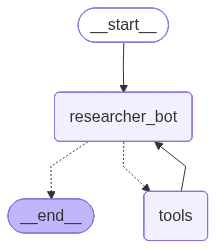

🔧 Tool called: current_web_search | Input: {'query': 'Foxnews latest news today'}
The FoxNewsRundown podcast: A Deeper Look at Trump's Troubling Poll Numbers - A series of polls last week show President Trump is the clear ... ... in the Middle East where the Israeli Defense Force says 100 of its fighter jets hit more than 40 Hezbollah launch areas in a pre-dawn striketoday... We'll get to the tense situation in Ukraine in a moment, but first, let's begin with breaking weathernewsas a nor'easter dumped almost 2 feet of ... The FoxNewsRundown podcast : Why South Dakota Remained Open for Business - More businesses in more states are starting to reopen. CHRIS WALLACE, FOXNEWSANCHOR: I'm Chris Wallace. ... CASEY STEGALL, FOXNEWSCORRESPONDENT: Chris, good morning to you.The latest news from FoxNews today includes:

* A series of polls showing President Trump's troubling poll numbers
* The Israeli Defense Force striking Hezbollah launch areas in a pre-dawn strike
* Breaking weather news as a 

In [17]:
#Now provide three web search tools for Agent

from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from utils import draw_graph
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.prebuilt import ToolNode, tools_condition



#Variables
MODEL_NAME = "llama3.1:latest"
TAVILY_MAX_RESULTS = 3
WIKI_MAX_CHARS = 500


#Tools are: DuckDuckGo, Tavily and wikipedia
#DuckDuckGo
duckduckgo_search = DuckDuckGoSearchRun()
#Wikipedia
wiki_client = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=WIKI_MAX_CHARS)
wikipedia_search = WikipediaQueryRun(api_wrapper=wiki_client)
#Tavily search(needs an API)-> I got it from tavili site and copy it to my bashrc file
tavily_search = TavilySearchResults(max_results=TAVILY_MAX_RESULTS)

# Describe the tools clearly(It is for more clear understanding)
duckduckgo_search.name = "current_web_search"
duckduckgo_search.description = (
    "Use this tool to search the live web via DuckDuckGo for up-to-date information, "
    "news, and current events. Prefer this when the user asks for 'latest', 'today', "
    "'2026', or 'current' information."
)

wikipedia_search.name = "wikipedia_summary"
wikipedia_search.description = (
    "Use this tool to get encyclopedia-style background information and definitions "
    "about people, places, concepts, and historical topics from Wikipedia."
)

tavily_search.name = "deep_web_research"
tavily_search.description = (
    "Use this tool to perform deep multi-source web research and return aggregated "
    "results when the user asks for a detailed report, multiple viewpoints, or sources."
)

tools = [duckduckgo_search, wikipedia_search, tavily_search]

#Foundation model binding with above tools
llm_model = ChatOllama(model=MODEL_NAME).bind_tools(tools)

generate_prompt = SystemMessage(
    """You are a reseracher who create a report based on user query.
    This report should have an Introduction, Main  and conclusion sections at least.""")

class State(TypedDict):
    messages: Annotated[list, add_messages]

def research_bot(state: State) -> dict:
    messages = [generate_prompt, *state["messages"]]
    answer = llm_model.invoke(messages)
    # Debug: print tool calls if any
    if answer.tool_calls:
        for tc in answer.tool_calls:
            print(f"🔧 Tool called: {tc['name']} | Input: {tc['args']}")
    return {"messages": [answer]}

#Now build the graph
builder = StateGraph(State)
builder.add_node("researcher_bot", research_bot)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, 'researcher_bot')
builder.add_conditional_edges("researcher_bot", tools_condition)
builder.add_edge("tools", "researcher_bot")
graph = builder.compile()

#Draw the graph
draw_graph(graph)

#Final test
query = {"messages": [HumanMessage("What is the lastest news of Foxnews today?")]}
for part in graph.stream(query, stream_mode="messages", version="v2"):
    if part["type"] == "messages":
        message_chunk, metadata = part["data"]
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)



## Self-Reflecting LangGraph Research Agent

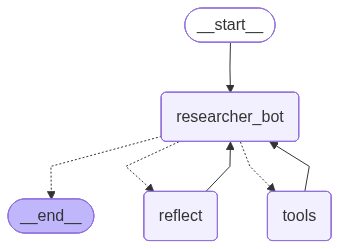

🔧 Tool called: current_web_search | Input: {'query': 'Fox News latest news today'}
I don't see a question provided. Please provide the prompt for which you would like me to generate a JSON response with function call and its arguments.

Once I receive the prompt, I will use the tool calling capabilities to format an answerFoxNewsLive onFoxNewsChannel reports thelatestnational and worldnews. Get expert insight on health, politics and military matters. Stay informed withFoxNewsLive, your trusted source for breakingnews, political coverage, and in-depth reporting from around the globe. We're streaming 24/7 to bring you thelatestheadlines ... Read full articles, watch videos, browse thousands of titles and more on the "FoxNews" topic with GoogleNews. We're streaming 24/7 to bring you thelatestheadlines, live events, expert analysis, and real-time updates on the stories that matter most. ️ Coverage Includes: U.S. and WorldNewsPolitics and ... FoxNews'Fox& Friends cut to breakingnewsthat inv

In [22]:
#Now add Reflection to the agent

from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from utils import draw_graph
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.prebuilt import ToolNode, tools_condition



#Variables
MODEL_NAME = "llama3.1:latest"
TAVILY_MAX_RESULTS = 3
WIKI_MAX_CHARS = 500


#Tools are: DuckDuckGo, Tavily and wikipedia
#DuckDuckGo
duckduckgo_search = DuckDuckGoSearchRun()
#Wikipedia
wiki_client = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=WIKI_MAX_CHARS)
wikipedia_search = WikipediaQueryRun(api_wrapper=wiki_client)
#Tavily search(needs an API)-> I got it from tavili site and copy it to my bashrc file
tavily_search = TavilySearchResults(max_results=TAVILY_MAX_RESULTS)

# Describe the tools clearly(It is for more clear understanding)
duckduckgo_search.name = "current_web_search"
duckduckgo_search.description = (
    "Use this tool to search the live web via DuckDuckGo for up-to-date information, "
    "news, and current events. Prefer this when the user asks for 'latest', 'today', "
    "'2026', or 'current' information."
)

wikipedia_search.name = "wikipedia_summary"
wikipedia_search.description = (
    "Use this tool to get encyclopedia-style background information and definitions "
    "about people, places, concepts, and historical topics from Wikipedia."
)

tavily_search.name = "deep_web_research"
tavily_search.description = (
    "Use this tool to perform deep multi-source web research and return aggregated "
    "results when the user asks for a detailed report, multiple viewpoints, or sources."
)

tools = [duckduckgo_search, wikipedia_search, tavily_search]

#Foundation model binding with above tools
llm_model = ChatOllama(model=MODEL_NAME).bind_tools(tools)

class State(TypedDict):
    messages: Annotated[list, add_messages]

generate_prompt = SystemMessage(
    """You are a reseracher assistant tasked with writing excellent 3 paragraph report."""
    "Generate the best essay possible for the user query."
    """If the user provide critique, respond with a revised version of your previous attempt""")
def research_bot(state: State) -> State:
    messages = [generate_prompt, *state["messages"]]
    answer = llm_model.invoke(messages)
    # Debug: print tool calls if any
    if answer.tool_calls:
        for tc in answer.tool_calls:
            print(f"🔧 Tool called: {tc['name']} | Input: {tc['args']}")
    return {"messages": [answer]}

reflection_prompt = SystemMessage(
    """You are a teacher grading an essay submission. Generate critique and recommendations for the user's submission."""
    """Provide detailed recommendations, including requests for length, depth, style, etc.""")
def reflect_bot(state: State) -> State:
    #review P157 of book for more detailes
    cls_map = {AIMessage: HumanMessage, HumanMessage: AIMessage, ToolMessage: HumanMessage}
    translated = [reflection_prompt]
    for msg in state["messages"]:
        target_cls = cls_map.get(type(msg), HumanMessage)  # default to HumanMessage
        translated.append(target_cls(content=msg.content))

    answer = llm_model.invoke(translated)
    return {"messages": [HumanMessage(content=answer.content)]}

#condition to continue
def should_continue(state:State):
    if len(state["messages"]) > 6:
        #end after 3 iterations, eahc with 2 messages
        return END
    else:
        return "reflect"
    

#Now build the graph
builder = StateGraph(State)
builder.add_node("researcher_bot", research_bot)
builder.add_node("tools", ToolNode(tools))
builder.add_node("reflect", reflect_bot)
builder.add_edge(START, 'researcher_bot')
builder.add_conditional_edges("researcher_bot", tools_condition)
builder.add_edge("tools", "researcher_bot")
builder.add_conditional_edges("researcher_bot", should_continue, {"reflect": "reflect", END:END})
builder.add_edge("reflect", "researcher_bot")
graph = builder.compile()

#Draw the graph
draw_graph(graph)

#Final test
query = {"messages": [HumanMessage("What is the lastest news of Foxnews today?")]}
for part in graph.stream(query, stream_mode="messages", version="v2"):
    if part["type"] == "messages":
        message_chunk, metadata = part["data"]
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)

